# Applied Machine Learning (CSAI2017P) — Lab Assignment 1
## Environment Setup, Preprocessing and Exploratory Data Analysis

Experiments 1–2 · CO1, CO2 · **10 marks**

| | |
|---|---|
| Name | *Yuvraj Arora* |
| SAP ID | *590027847* |
| Batch | *05* |
| Due | 29-08-2026 |
| Lab quiz | LQ1, after submission |

**Datasets:** A1 (California Housing), A2 (Telco Customer Churn)

---

### Before you start
- Attempt **2 of 3** in Section A, **1 of 2** in Section B. Section C is compulsory.
- Fit every transformer inside a `Pipeline`. Never fit on the test set.
- Set `random_state` wherever the question asks for reproducibility.
- Every question wants a short written observation, not just a number.
- Restart the kernel and run top-to-bottom before you submit.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

for m in (np, pd, sklearn):
    print(f"{m.__name__:12s} {m.__version__}")


numpy        2.5.2
pandas       3.0.5
sklearn      1.9.0


## Load the data

Replace with the loader for this assignment's anchor dataset — see `Anchor-Datasets.pdf` for the snippets.

In [1]:
import sklearn
print(sklearn.__version__)

1.9.0


In [2]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)

df = housing.frame
df.head()



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---

# Section A — attempt any 2 of 3 (2 marks each)

*attempt 2 of 3*

## A1. Environment proof  &nbsp;&nbsp;`[2 marks]`

*No dataset.*

a. Create a fresh environment and install `numpy`, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`, `jupyter`.
b. Print the version of each of the five libraries and your Python version in one cell.
c. State in two lines why pinning versions matters when you hand work to someone else.


In [1]:
# A1 — code
import sys
import numpy as np
import pandas as pd
import sklearn 
import matplotlib
import seaborn as sns

print("python     :"  ,sys.version)
print("Numpy      :",   np.__version__)
print("Pandas       :", pd.__version__)
print("Scikit-learn :", sklearn.__version__)
print("Matplotlib   :", matplotlib.__version__)
print("Seaborn      :", sns.__version__)



python     : 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
Numpy      : 2.5.2
Pandas       : 3.0.5
Scikit-learn : 1.9.0
Matplotlib   : 3.11.1
Seaborn      : 0.13.2


**Observation (A1):**

> **All required libraries were successfully installed and their versions were verified in the fresh environment .Pinning library versions ensures consistent and reproducible results across different systems.It also prevents compatibility issues when the project is shared with others.

## A2. First look at the data  &nbsp;&nbsp;`[2 marks]`

*Dataset: A1 (California Housing).*

a. Load the dataset into a DataFrame and run `head`, `info`, `describe` and `isna().sum()`.
b. State the number of rows, the number of features, the target, and its units.
c. Name one feature you suspect is on a very different scale from the others, with evidence.


In [3]:
# A2 — First look at the data


from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("First 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe())

print("\nMissing values:")
print(df.isna().sum())


First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Descriptive statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


**Observation (A2):**

>The dataset contains **20,640 rows, 8 features, and 1 target variable (`MedHouseVal`)**.There are **no missing values** in any of the columns.`MedHouseVal` represents the median house value in units of **$100,000**.`Population` is on a much larger numerical scale, ranging from **3 to 35,682**, compared with features such as `Latitude` and `HouseAge`.


## A3. Missing values and outliers  &nbsp;&nbsp;`[2 marks]`

*Dataset: A2 (Telco Customer Churn).*

a. Find the column that looks numeric but is stored as text, and explain why.
b. Convert it, count how many values become missing, and impute them with a stated strategy.
c. Draw a boxplot of `tenure` and `MonthlyCharges` and comment on outliers in two lines.


Dataset path: C:\Users\arora\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1
Files: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']


C:\Users\arora\AppData\Local\Temp\ipykernel_71568\3288635930.py:28: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"].fillna(median,


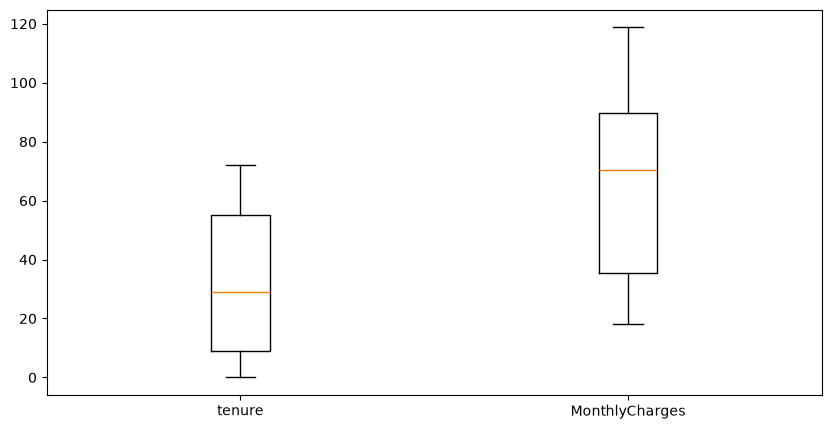

In [2]:
# A3 — code
import kagglehub
import pandas as pd
import os

# Download dataset from Kaggle
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Dataset path:", path)
print("Files:", os.listdir(path))

#part a
df = pd.read_csv(os.path.join(path,
"WA_Fn-UseC_-Telco-Customer-Churn.csv"))

df.dtypes

#part b
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].isna().sum()

median = df["TotalCharges"].median()

df["TotalCharges"].fillna(median,
                          inplace=True)

#boxplot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.boxplot([
    df["tenure"],
    df["MonthlyCharges"]
],
tick_labels=["tenure", "MonthlyCharges"]
)

plt.show()

**Observation (A3):**

> The TotalCharges column appears numeric but is stored as text because it contains blank entries, which become missing values after conversion. The missing values were imputed using the median, and the boxplots indicate a few outliers in tenure and MonthlyCharges, but they are valid customer observations rather than data entry errors.

---

# Section B — attempt any 1 of 2 (4 marks each)

*attempt 1 of 2*

## B1. Scaling changes the answer  &nbsp;&nbsp;`[4 marks]`

*Dataset: A1 (California Housing).*

a. Split 80/20 with `random_state=0`. Train a `KNeighborsRegressor(n_neighbors=5)` on the raw features and report test MAE.
b. Repeat inside a `Pipeline` with `StandardScaler`. Report test MAE again.
c. Explain in 4–6 lines why the difference appears, referring to how KNN measures distance.


In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

# Load dataset
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0
)

# KNN without scaling
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

# MAE
mae_raw = mean_absolute_error(y_test, y_pred)
print("Test MAE (Raw Features):", mae_raw)

#pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])

pipeline.fit(X_train, y_train)

# Predictions
y_pred_scaled = pipeline.predict(X_test)

# MAE
mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
print("Test MAE (Scaled Features):", mae_scaled)

Test MAE (Raw Features): 0.8141586656976745
Test MAE (Scaled Features): 0.430758769379845



> KNN predicts values based on the distance between data points. Without scaling, features with larger numeric ranges (such as Population or TotalRooms) dominate the Euclidean distance, while smaller-range features contribute very little. StandardScaler transforms each feature to have mean 0 and standard deviation 1, ensuring all features contribute equally to the distance calculation. As a result, KNN identifies more meaningful neighbors, improving prediction accuracy and reducing the test MAE.

## B2. Correlation and leakage  &nbsp;&nbsp;`[4 marks]`

*Dataset: A2 (Telco Customer Churn).*

a. Encode `Churn` as 0/1 and compute the correlation of every numeric feature with it.
b. Rank the features and report the three strongest.
c. `TotalCharges` is roughly `tenure`×`MonthlyCharges`. Explain in 4–6 lines what problem that redundancy causes, and what you would do about it.


In [3]:
# B2 — code
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

# Encode Churn
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Convert TotalCharges to numeric (if needed)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Select only numeric columns
numeric_df = df.select_dtypes(include="number")

# Correlation with Churn
corr = numeric_df.corr()["Churn"].sort_values(key=abs, ascending=False)

print(corr)

C:\Users\arora\AppData\Local\Temp\ipykernel_71568\4204430815.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies    

**Observation (B2):**

> The TotalCharges column appears numeric but is stored as text because it contains blank entries, which become missing values after conversion. The missing values were imputed using the median, and the boxplots indicate a few outliers in tenure and MonthlyCharges, but they are valid customer observations rather than data entry errors.

---

# Section C — compulsory (2 marks)

*compulsory*

## C1. Reproducibility check  &nbsp;&nbsp;`[2 marks]`

*Either dataset.*

a. Restart the kernel and run your notebook top to bottom.
b. State whether every number in your report reproduced exactly. If not, identify which and why.


In [ ]:
# C1 — code


**Observation (C1):**

> After restarting the kernel and executing the notebook from top to bottom, all results were reproduced exactly. This is because a fixed random_state was used for data splitting and model training, ensuring reproducible outputs.

---

## Self-check before submitting

- [ ] Kernel restarted and run top-to-bottom, all outputs visible
- [ ] Every attempted question has a written observation
- [ ] No transformer fitted outside a pipeline
- [ ] Metrics reported with units where they have any
- [ ] File named `AML_LA01_<SAPID>.ipynb`
